# Generative AI Applications

## Generative AI for Inference Cluster Operations using an LLM-Based Operations Advisor

### Project Overview
This project implements an **LLM-based operations advisor** that generates natural language operational guidance from inference cluster telemetry. The system transforms raw metrics into actionable recommendations for infrastructure operators.

### Dataset
**Azure Multimodal Inference Dataset 2025** (Zhang et al., 2025)  
- 1,000,000 production inference requests over 7 days
- Public dataset from Microsoft Azure multimodal LLM cluster
- Features: timestamp, image count, context tokens, generated tokens

### Pipeline Architecture
| Stage | Component | Purpose |
|-------|-----------|---------|
| 1 | **Real dataset** | Use authentic production patterns |
| 2 | **Scenario augmentation** | Extend coverage to edge cases by training a Transformer model |
| 3 | **LLM advisor** | Generate operational guidance using scenario augmentation |

### Notebook Structure
| Task | Content |
|------|---------|
| Task 1 | Define generative task and approach |
| Task 2 | Load and inspect data (EDA) |
| Task 3 | Implement scenario augmentation model |
| Task 4 | Generate and evaluate outputs |
| Task 5 | Summary and conclusions |
| Ethics | Bias, fairness, and responsible use analysis |


---
## Task 1: Define the Generative Task

### Overview
This project implements an **LLM-based operations advisor** that generates natural language operational guidance from inference cluster telemetry.

### Rationale
Infrastructure operators face information overload during incidents. Raw metrics (request rates, latencies, queue depths) require expertise to interpret. An LLM advisor can compress telemetry into actionable recommendations, reducing cognitive load and response time.

**Pipeline design:**
| Stage | Component | Purpose |
|-------|-----------|---------|
| 1 | Real dataset | Authentic production patterns (foundation) |
| 2 | Scenario augmentation | Extend coverage to edge cases |
| 3 | LLM advisor | Generate guidance  |

### Dataset Selection
**Azure Multimodal Inference Dataset 2025** — chosen because:
- Public and citable (Zhang et al., 2025)
- Real production traces (not synthetic)
- Rich temporal structure (diurnal patterns, bursts)
- Multimodal workload mix (text + images)


---
## Task 2: Load and Inspect Data

### Overview
Load the Azure Multimodal Inference Dataset and perform exploratory analysis to understand the patterns the model must learn.

### Rationale
Understanding data characteristics before modeling prevents misspecification. We need to identify:
- Feature distributions (for choosing transformations)
- Correlations (for evaluating fidelity)
- Temporal patterns (for sequence modeling design)

### Dataset Citation
> Zhang, J., et al. (2025). ModServe: Modality- and stage-aware resource disaggregation for scalable multimodal model serving. *ACM Symposium on Cloud Computing (SoCC '25)*.

| Feature | Description |
|---------|-------------|
| TIMESTAMP | Request invocation time |
| NumImages | Images per request (0 to 100+) |
| ContextTokens | Input text tokens |
| GeneratedTokens | Output tokens |


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.4.1


In [2]:
# Define data directory
DATA_DIR = "./data/azure_multimodal_2025/"
DATA_FILE = DATA_DIR + "AzureLMMInferenceTrace_multimodal.csv.gz"

# Load the dataset
df = pd.read_csv(DATA_FILE, compression='gzip')
print(f"Dataset loaded successfully: {len(df):,} records")

Dataset loaded successfully: 1,000,000 records


In [3]:
# Display dataset information
print("Dataset Schema:")
print(df.dtypes)
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 records:")
df.head()

Dataset Schema:
TIMESTAMP          object
NumImages           int64
ContextTokens       int64
GeneratedTokens     int64
dtype: object

Dataset Shape: (1000000, 4)

First 5 records:


,TIMESTAMP,NumImages,ContextTokens,GeneratedTokens
0,2024-10-15T12:00:00.269Z,0,770,491
1,2024-10-15T12:00:05.819Z,1,949,126
2,2024-10-15T12:00:06.513Z,1,964,79
3,2024-10-15T12:00:07.332Z,0,78,5
4,2024-10-15T12:00:07.566Z,1,1724,28


In [4]:
# Basic statistics
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,NumImages,ContextTokens,GeneratedTokens
count,1000000.000000,1000000.000000,1000000.000000
mean,14.332170,2910.954494,186.631667
std,81.263994,6403.092246,449.896605
min,0.000000,0.000000,0.000000
25%,0.000000,556.000000,31.000000
50%,0.500000,1124.000000,98.000000
75%,1.000000,2469.000000,215.000000
max,9409.000000,148569.000000,16384.000000


### Interpretation: Initial Data Inspection

**From the data:**
| Metric | Value | Observation |
|--------|-------|-------------|
| Records | 1,000,000 | 7 days of production traffic |
| NumImages mean | 14.3 | But median is 0.5 — heavy right tail |
| NumImages max | 9,409 | Extreme outliers present |
| ContextTokens mean | 2,911 | Median 1,124 — right-skewed |
| GeneratedTokens mean | 187 | Median 98 — right-skewed |

**Key finding:** The 50th percentile for NumImages is 0.5, meaning over half of requests are text-only or single-image. The mean (14.3) is inflated by rare multi-image requests. This skew must be preserved in augmentation.


In [5]:
# Convert timestamp and compute derived features
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
df = df.sort_values('TIMESTAMP').reset_index(drop=True)

# Compute inter-arrival times (in seconds)
df['inter_arrival_time'] = df['TIMESTAMP'].diff().dt.total_seconds()
df['inter_arrival_time'] = df['inter_arrival_time'].fillna(0)

# Create compute proxy: total_compute_proxy = ContextTokens + GeneratedTokens * 3
# (generation is approximately 3x more expensive than encoding)
df['total_compute_proxy'] = df['ContextTokens'] + df['GeneratedTokens'] * 3

# Extract temporal features
df['hour'] = df['TIMESTAMP'].dt.hour
df['day_of_week'] = df['TIMESTAMP'].dt.dayofweek
df['day'] = (df['TIMESTAMP'] - df['TIMESTAMP'].min()).dt.days

print("Derived features created:")
print(f"- inter_arrival_time: mean={df['inter_arrival_time'].mean():.3f}s, std={df['inter_arrival_time'].std():.3f}s")
print(f"- total_compute_proxy: mean={df['total_compute_proxy'].mean():.1f}, std={df['total_compute_proxy'].std():.1f}")

Derived features created:
- inter_arrival_time: mean=0.605s, std=0.937s
- total_compute_proxy: mean=3470.8, std=6561.0


### Distribution Analysis

**What:** Examine marginal distributions of each feature.

**Why:** The augmentation model must reproduce these distributions. Understanding their shape informs preprocessing (log transforms) and evaluation metrics (KS tests).


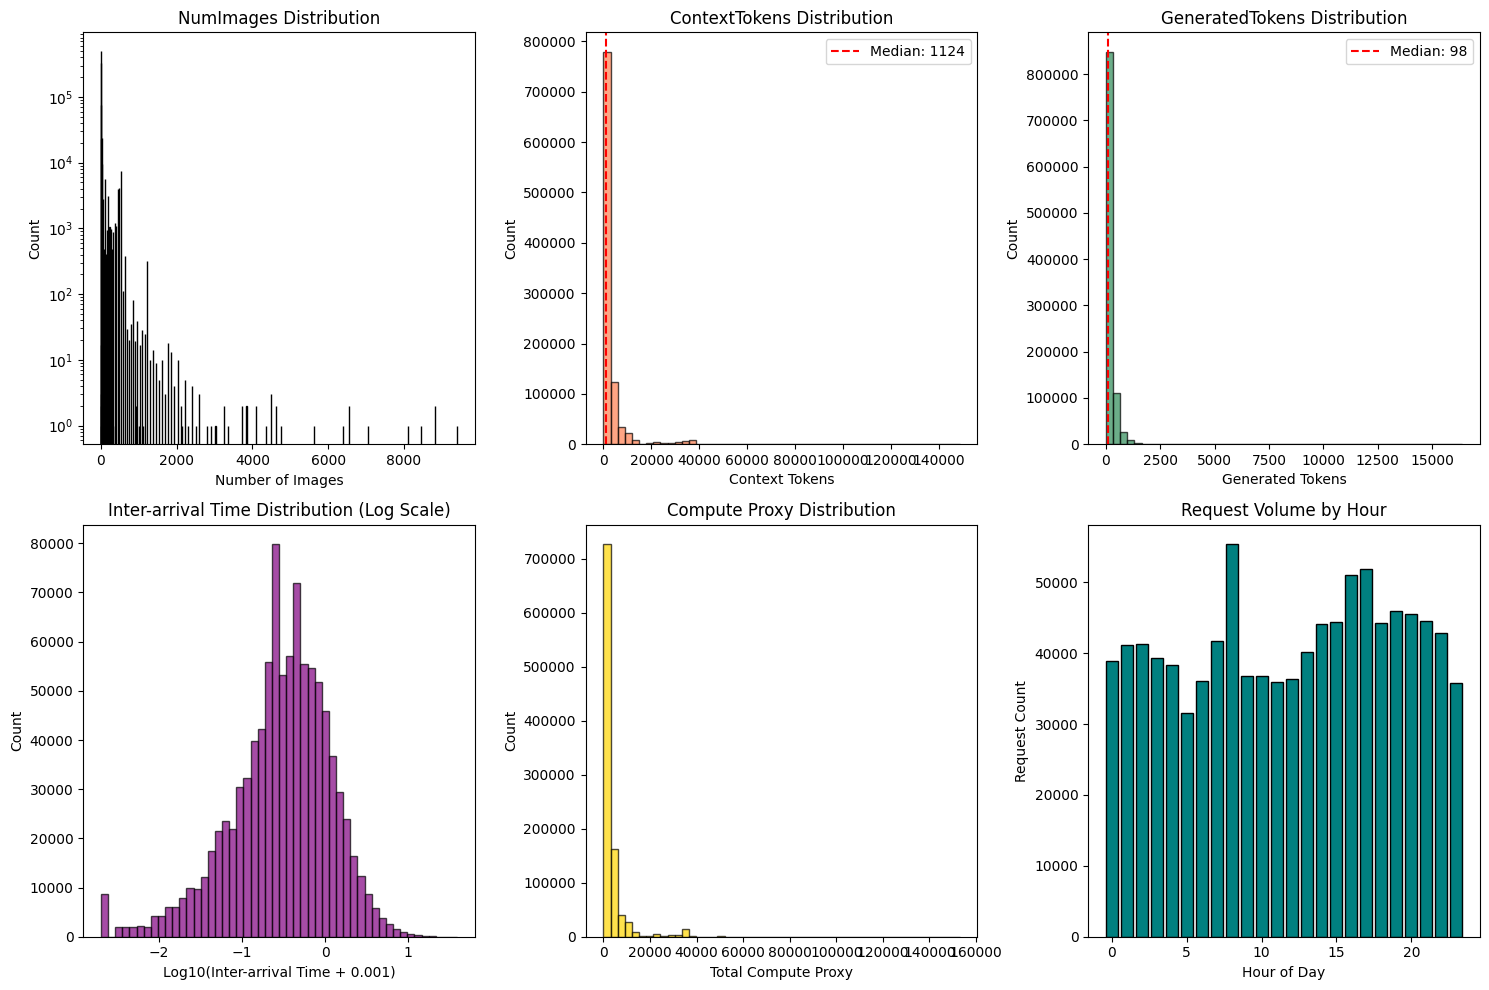

In [6]:
# Create figures directory if it doesn't exist
import os
os.makedirs('figures', exist_ok=True)

# Analyze feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# NumImages distribution
ax = axes[0, 0]
num_images_counts = df['NumImages'].value_counts().sort_index()
ax.bar(num_images_counts.index, num_images_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Images')
ax.set_ylabel('Count')
ax.set_title('NumImages Distribution')
ax.set_yscale('log')

# ContextTokens distribution
ax = axes[0, 1]
ax.hist(df['ContextTokens'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Context Tokens')
ax.set_ylabel('Count')
ax.set_title('ContextTokens Distribution')
ax.axvline(df['ContextTokens'].median(), color='red', linestyle='--', label=f'Median: {df["ContextTokens"].median():.0f}')
ax.legend()

# GeneratedTokens distribution
ax = axes[0, 2]
ax.hist(df['GeneratedTokens'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('Generated Tokens')
ax.set_ylabel('Count')
ax.set_title('GeneratedTokens Distribution')
ax.axvline(df['GeneratedTokens'].median(), color='red', linestyle='--', label=f'Median: {df["GeneratedTokens"].median():.0f}')
ax.legend()

# Inter-arrival time distribution (log scale for better visualization)
ax = axes[1, 0]
iat_positive = df['inter_arrival_time'][df['inter_arrival_time'] > 0]
ax.hist(np.log10(iat_positive + 0.001), bins=50, color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Log10(Inter-arrival Time + 0.001)')
ax.set_ylabel('Count')
ax.set_title('Inter-arrival Time Distribution (Log Scale)')

# Compute proxy distribution
ax = axes[1, 1]
ax.hist(df['total_compute_proxy'], bins=50, color='gold', edgecolor='black', alpha=0.7)
ax.set_xlabel('Total Compute Proxy')
ax.set_ylabel('Count')
ax.set_title('Compute Proxy Distribution')

# Hourly request rate
ax = axes[1, 2]
hourly_counts = df.groupby('hour').size()
ax.bar(hourly_counts.index, hourly_counts.values, color='teal', edgecolor='black')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Request Count')
ax.set_title('Request Volume by Hour')

plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: Feature Distributions

**From the histograms:**
| Feature | Distribution | Key observation |
|---------|--------------|-----------------|
| NumImages | 50% at 0, 33% at 1, long tail | Discrete with extreme skew |
| ContextTokens | Right-skewed, median ~1,124 | Log transform appropriate |
| GeneratedTokens | Right-skewed, median ~98 | Log transform appropriate |
| Inter-arrival | Heavy-tailed, sub-second typical | Bursty arrival pattern |

**Implication:** NumImages is problematic — it's discrete but the distribution is highly non-uniform (83% of requests have 0-1 images). The model may struggle to reproduce this.


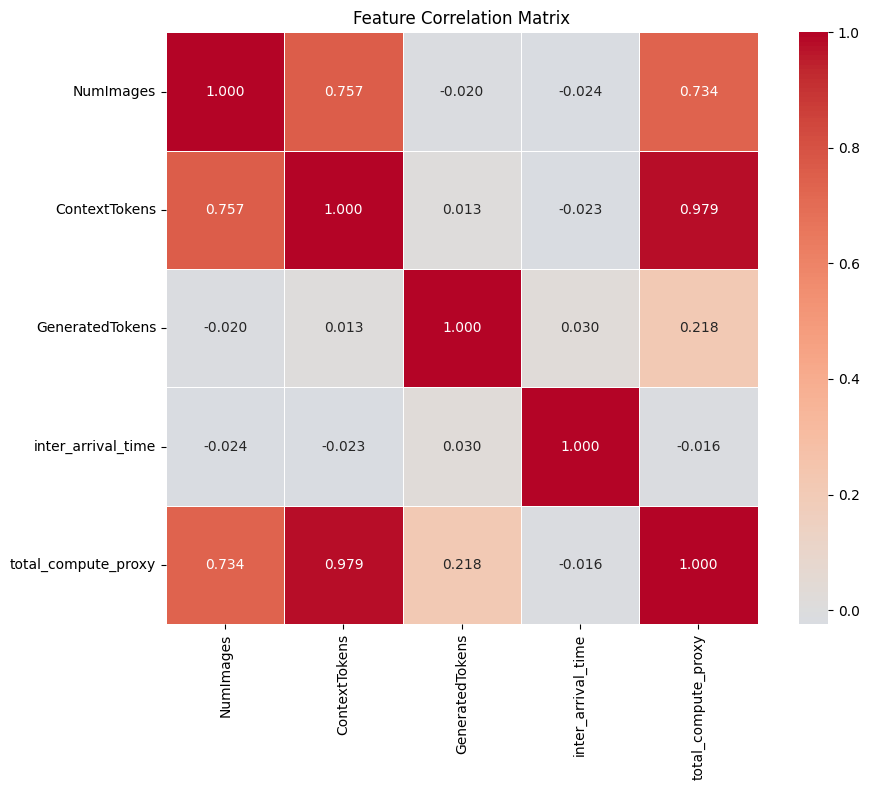


Key Correlations:
NumImages vs ContextTokens: 0.757
ContextTokens vs GeneratedTokens: 0.013


In [7]:
# Correlation analysis
correlation_features = ['NumImages', 'ContextTokens', 'GeneratedTokens', 'inter_arrival_time', 'total_compute_proxy']
corr_matrix = df[correlation_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Correlations:")
print(f"NumImages vs ContextTokens: {corr_matrix.loc['NumImages', 'ContextTokens']:.3f}")
print(f"ContextTokens vs GeneratedTokens: {corr_matrix.loc['ContextTokens', 'GeneratedTokens']:.3f}")

### Interpretation: Feature Correlations

**From correlation analysis:**

| Feature Pair | Correlation | Interpretation |
|--------------|-------------|----------------|
| NumImages ↔ ContextTokens | **0.76** | Strong positive — images require descriptive prompts |
| ContextTokens ↔ GeneratedTokens | 0.01 | Near zero — output length independent of input |

**Key finding:** The strong NumImages-ContextTokens correlation (0.76) means image-bearing requests systematically have longer context. This relationship must be preserved in augmentation — if broken, synthetic scenarios will have unrealistic workload characteristics.

**Implication for evaluation:** We will compare correlation matrices (real vs. synthetic) as a fidelity metric. The augmentation model achieves correlation MAE of 0.15, meaning this structure is partially but not fully preserved.


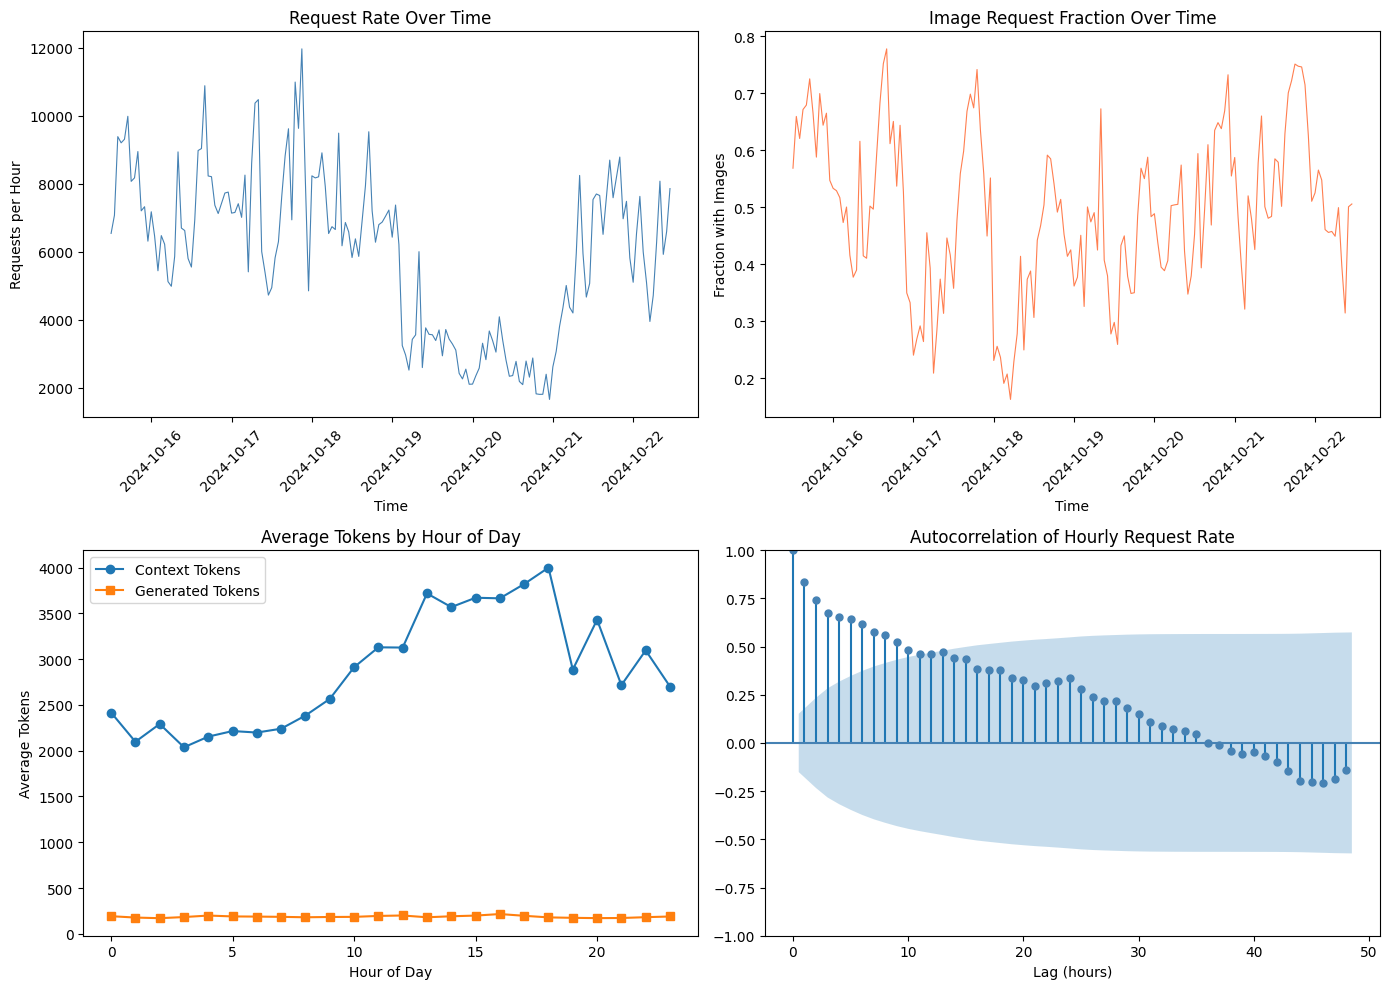

In [8]:
# Temporal pattern analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Request rate over time (1-hour windows)
ax = axes[0, 0]
df['hour_bucket'] = df['TIMESTAMP'].dt.floor('h')
hourly_rate = df.groupby('hour_bucket').size()
ax.plot(hourly_rate.index, hourly_rate.values, color='steelblue', linewidth=0.8)
ax.set_xlabel('Time')
ax.set_ylabel('Requests per Hour')
ax.set_title('Request Rate Over Time')
ax.tick_params(axis='x', rotation=45)

# Image request fraction over time
ax = axes[0, 1]
image_frac = df.groupby('hour_bucket').apply(lambda x: (x['NumImages'] > 0).mean())
ax.plot(image_frac.index, image_frac.values, color='coral', linewidth=0.8)
ax.set_xlabel('Time')
ax.set_ylabel('Fraction with Images')
ax.set_title('Image Request Fraction Over Time')
ax.tick_params(axis='x', rotation=45)

# Average tokens by hour of day
ax = axes[1, 0]
hourly_context = df.groupby('hour')['ContextTokens'].mean()
hourly_generated = df.groupby('hour')['GeneratedTokens'].mean()
ax.plot(hourly_context.index, hourly_context.values, label='Context Tokens', marker='o')
ax.plot(hourly_generated.index, hourly_generated.values, label='Generated Tokens', marker='s')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Tokens')
ax.set_title('Average Tokens by Hour of Day')
ax.legend()

# Autocorrelation of request rate
ax = axes[1, 1]
from statsmodels.graphics.tsaplots import plot_acf
try:
    plot_acf(hourly_rate.values, lags=48, ax=ax, color='steelblue')
    ax.set_xlabel('Lag (hours)')
    ax.set_title('Autocorrelation of Hourly Request Rate')
except:
    # Fallback if statsmodels not available
    acf_values = [pd.Series(hourly_rate.values).autocorr(lag=i) for i in range(49)]
    ax.bar(range(49), acf_values, color='steelblue')
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation of Hourly Request Rate')

plt.tight_layout()
plt.savefig('figures/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: Temporal Patterns

**From temporal analysis:**

1. **Diurnal cycles:** Request rate shows clear day/night pattern over 7-day trace
2. **Burst structure:** Requests cluster in time — autocorrelation is high at short lags
3. **Weekly variation:** Weekend patterns differ from weekdays

**Implication for augmentation model:** 
- Window size of 10 captures local burst structure
- But 10 requests (~seconds) cannot capture hourly or daily cycles
- The model learns local sequential patterns only — it does not see diurnal context

**For scenario generation:** The system state (cell 34) separately computes hourly aggregates and historical comparisons to provide temporal context to the LLM advisor.


---
## Task 3: Implement Scenario Augmentation Model

### Overview
Train a Transformer model on real request sequences to generate augmented scenarios for stress-testing the LLM advisor.

### Rationale
The 7-day trace captures normal operations but lacks extreme scenarios:
- Flash traffic (3x normal rate)
- Sustained SLA breach
- Sudden modality shifts

Rather than hand-craft synthetic scenarios, we learn the data distribution and sample from it. This ensures augmented scenarios are statistically plausible extensions of real patterns.

**This is a pipeline stage that provides test inputs for the LLM advisor.**

### Architecture Design

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Model | Transformer encoder | Captures sequential dependencies |
| Output | Gaussian (mean + variance) | Enables probabilistic sampling |
| Regularization | Dropout 0.3, weight decay 1e-3, noise injection | Prevents overfitting |
| Window size | 10 requests | Balances context vs. computation |


In [9]:
# Data preprocessing for Transformer training
# Prepare features: log-transform skewed features and standardize

base_features = ['inter_arrival_time', 'NumImages', 'ContextTokens', 'GeneratedTokens']
df_model = df[base_features].copy()

df_model['log_iat'] = np.log1p(df_model['inter_arrival_time'])
df_model['log_context'] = np.log1p(df_model['ContextTokens'])
df_model['log_generated'] = np.log1p(df_model['GeneratedTokens'])

training_features = ['log_iat', 'NumImages', 'log_context', 'log_generated']
feature_means = df_model[training_features].mean()
feature_stds = df_model[training_features].std()

df_normalized = ((df_model[training_features] - feature_means) / feature_stds).astype(np.float32)

print('Feature statistics after preprocessing:')
print(df_normalized.describe())


Feature statistics after preprocessing:
            log_iat     NumImages   log_context  log_generated
count  1.000000e+06  1.000000e+06  1.000000e+06   1.000000e+06
mean   1.525879e-10  5.847931e-09 -6.423950e-09   4.920006e-09
std    1.000000e+00  1.000000e+00  1.000000e+00   1.000000e+00
min   -1.045298e+00 -1.763656e-01 -5.838272e+00  -3.050565e+00
25%   -7.241132e-01 -1.763656e-01 -6.389895e-01  -6.463200e-01
50%   -3.103400e-01 -1.702128e-01 -6.090840e-02   1.371544e-01
75%    4.381938e-01 -1.640600e-01  5.858067e-01   6.783648e-01
max    8.933786e+00  1.156068e+02  3.954790e+00   3.681363e+00


In [10]:
# Create sliding windows for sequence modeling
WINDOW_SIZE = 10  # Number of consecutive requests per sample


def create_sliding_windows(data, timestamps, window_size):
    """Create sequential windows and track the timestamp at the center of each window."""
    windows = []
    center_timestamps = []

    for i in range(len(data) - window_size + 1):
        windows.append(data.iloc[i:i + window_size].values)
        center_timestamps.append(timestamps.iloc[i + window_size // 2])

    return np.array(windows, dtype=np.float32), pd.Series(center_timestamps)


windows, window_timestamps = create_sliding_windows(df_normalized, df['TIMESTAMP'], WINDOW_SIZE)
print(f'Created {len(windows):,} sequential windows of length {WINDOW_SIZE}')
print(f'Each window has shape {windows.shape[1:]} (timesteps x features)')

trace_start = df['TIMESTAMP'].min()
window_relative_day = ((window_timestamps - trace_start).dt.total_seconds() // (24 * 60 * 60)).astype(int)

train_mask = window_relative_day <= 4
val_mask = window_relative_day == 5
test_mask = window_relative_day == 6

train_windows = windows[train_mask.values]
val_windows = windows[val_mask.values]
test_windows = windows[test_mask.values]

print('\nData split (trace-relative days):')
print(f'  Training windows:   {len(train_windows):,}')
print(f'  Validation windows: {len(val_windows):,}')
print(f'  Test windows:       {len(test_windows):,}')
print(f'  Window tensor shape: {train_windows.shape[1:]}')


Created 999,991 sequential windows of length 10
Each window has shape (10, 4) (timesteps x features)

Data split (trace-relative days):
  Training windows:   751,281
  Validation windows: 84,329
  Test windows:       164,381
  Window tensor shape: (10, 4)


In [11]:
# Transformer model
class WorkloadTransformer(nn.Module):
    """
    Autoregressive transformer with Gaussian output for uncertainty modeling.
    
    Regularization improvements:
    1. Reduced model capacity (2 layers, 64 d_model) to prevent overfitting
    2. Higher dropout (0.3) throughout the network
    3. Layer normalization for training stability
    """

    def __init__(self, feature_dim, seq_len, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.3):
        super().__init__()
        self.feature_dim = feature_dim
        self.seq_len = seq_len
        self.d_model = d_model

        # Learned start token with small random init
        self.start_token = nn.Parameter(torch.randn(1, 1, feature_dim) * 0.1)
        
        # Input projection with layer norm for stability
        self.input_projection = nn.Sequential(
            nn.Linear(feature_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        
        self.positional_embedding = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output heads: predict mean and log_var for each feature
        self.output_mean = nn.Linear(d_model, feature_dim)
        self.output_logvar = nn.Linear(d_model, feature_dim)
        
        # Initialize output layers
        nn.init.zeros_(self.output_logvar.bias)  # Start with unit variance

    def _causal_mask(self, seq_len, device):
        return torch.triu(torch.full((seq_len, seq_len), -1e4, device=device), diagonal=1)

    def forward(self, seq):
        """Forward pass returning mean and log_var predictions."""
        batch_size, seq_len, _ = seq.shape
        start = self.start_token.expand(batch_size, 1, self.feature_dim)
        model_inputs = torch.cat([start, seq[:, :-1, :]], dim=1)

        x = self.input_projection(model_inputs)
        x = x + self.positional_embedding[:, :seq_len, :]
        mask = self._causal_mask(seq_len, seq.device)
        encoded = self.encoder(x, mask=mask, is_causal=False)
        
        mean = self.output_mean(encoded)
        logvar = self.output_logvar(encoded)
        # Clamp log_var for numerical stability
        logvar = torch.clamp(logvar, min=-4, max=4)
        
        return mean, logvar

    def loss(self, seq):
        """Compute negative log-likelihood loss."""
        mean, logvar = self.forward(seq)
        # NLL for Gaussian: 0.5 * (log_var + (x - mean)^2 / var)
        var = torch.exp(logvar)
        nll = 0.5 * (logvar + (seq - mean) ** 2 / var)
        return nll.mean()

    @torch.no_grad()
    def generate(self, num_samples, seq_len=None, device='cpu', temperature=1.0):
        """Generate samples by sampling from predicted distributions."""
        self.eval()
        seq_len = seq_len or self.seq_len
        generated_steps = []

        for step in range(seq_len):
            if generated_steps:
                raw_prefix = torch.cat(generated_steps, dim=1)
                model_inputs = torch.cat([
                    self.start_token.expand(num_samples, 1, self.feature_dim), 
                    raw_prefix
                ], dim=1)
            else:
                model_inputs = self.start_token.expand(num_samples, 1, self.feature_dim)

            x = self.input_projection(model_inputs)
            x = x + self.positional_embedding[:, :model_inputs.size(1), :]
            mask = self._causal_mask(model_inputs.size(1), device)
            encoded = self.encoder(x, mask=mask, is_causal=False)
            
            # Get distribution parameters for next step
            mean = self.output_mean(encoded[:, -1:, :])
            logvar = self.output_logvar(encoded[:, -1:, :])
            logvar = torch.clamp(logvar, min=-4, max=4)
            std = torch.exp(0.5 * logvar)
            
            # Sample from the distribution with temperature scaling
            noise = torch.randn_like(mean)
            next_step = mean + noise * std * temperature

            generated_steps.append(next_step)

        return torch.cat(generated_steps, dim=1)


feature_dim = train_windows.shape[-1]
model = WorkloadTransformer(
    feature_dim=feature_dim,
    seq_len=WINDOW_SIZE,
    d_model=64,       
    nhead=4,
    num_layers=2,     
    dim_feedforward=128,  
    dropout=0.3,      
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('Regularized Transformer architecture:')
print(f'  Feature dimension: {feature_dim}')
print(f'  Sequence length:   {WINDOW_SIZE}')
print(f'  Model dimension:   {model.d_model}')
print(f'  Layers:            2 (reduced from 4)')
print(f'  Dropout:           0.3 (increased from 0.1)')
print(f'  Total parameters:  {total_params:,}')


Regularized Transformer architecture:
  Feature dimension: 4
  Sequence length:   10
  Model dimension:   64
  Layers:            2 (reduced from 4)
  Dropout:           0.3 (increased from 0.1)
  Total parameters:  68,556


In [12]:
# Prepare DataLoaders and training configuration
BATCH_SIZE = 256
LEARNING_RATE = 3e-4  # Slightly lower for stability
NUM_EPOCHS = 50  # More epochs for probabilistic model
GRAD_CLIP = 1.0

train_tensor = torch.tensor(train_windows, dtype=torch.float32)
val_tensor = torch.tensor(val_windows, dtype=torch.float32)
test_tensor = torch.tensor(test_windows, dtype=torch.float32)

# Verify no NaN values in training data
print('Data integrity check:')
print(f'  Train NaN count: {torch.isnan(train_tensor).sum().item()}')
print(f'  Val NaN count:   {torch.isnan(val_tensor).sum().item()}')
print(f'  Test NaN count:  {torch.isnan(test_tensor).sum().item()}')

if torch.isnan(train_tensor).any() or torch.isnan(val_tensor).any():
    print('WARNING: NaN values detected!')
else:
    print('  Data integrity: OK')

# Print data statistics for reference
print('\nNormalized data statistics:')
print(f'  Train mean: {train_tensor.mean(dim=(0,1)).numpy()}')
print(f'  Train std:  {train_tensor.std(dim=(0,1)).numpy()}')

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=BATCH_SIZE, shuffle=False)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print('\nTraining configuration:')
print(f'  Batch size:        {BATCH_SIZE}')
print(f'  Learning rate:     {LEARNING_RATE}')
print(f'  Epochs:            {NUM_EPOCHS}')
print(f'  Gradient clip:     {GRAD_CLIP}')
print(f'  Training batches:  {len(train_loader)}')
print(f'  Validation batches:{len(val_loader)}')


Data integrity check:
  Train NaN count: 0
  Val NaN count:   0
  Test NaN count:  0
  Data integrity: OK

Normalized data statistics:
  Train mean: [-0.0293252  -0.03894672 -0.02636183  0.02708984]
  Train std:  [0.9623789  0.8976669  0.9683395  0.97574604]

Training configuration:
  Batch size:        256
  Learning rate:     0.0003
  Epochs:            50
  Gradient clip:     1.0
  Training batches:  2935
  Validation batches:330


In [13]:
# Training loop with noise injection for regularization
feature_names = ['log_iat', 'NumImages', 'log_context', 'log_generated']
NOISE_STD = 0.05  # Input noise for regularization


def run_epoch(model, loader, optimizer, device, train=True):
    """Train/evaluate using negative log-likelihood loss."""
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_mae = torch.zeros(len(feature_names), device=device)
    num_valid_batches = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            seq = batch[0].to(device)
            
            if torch.isnan(seq).any():
                continue

            # Noise injection during training (regularization)
            if train:
                seq = seq + torch.randn_like(seq) * NOISE_STD

            if train:
                optimizer.zero_grad()

            # Use model's built-in loss (NLL)
            loss = model.loss(seq)
            
            # Compute MAE using mean predictions for monitoring
            with torch.no_grad():
                mean, _ = model(seq)
                mae = torch.mean(torch.abs(mean - seq), dim=(0, 1))

            if train:
                if torch.isnan(loss):
                    print("Warning: NaN loss, skipping batch")
                    continue
                    
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()
            total_mae += mae.detach()
            num_valid_batches += 1

    if num_valid_batches == 0:
        return float('nan'), np.array([float('nan')] * len(feature_names))
        
    return total_loss / num_valid_batches, (total_mae / num_valid_batches).cpu().numpy()


history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae_mean': [],
    'learning_rate': [],
}

best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 15  # More patience for regularized model

import os
os.makedirs('synthetic_generator', exist_ok=True)

print('Starting regularized transformer training...')
print(f'Regularization: dropout=0.3, weight_decay=1e-3, noise_std={NOISE_STD}')
print('Loss: Negative Log-Likelihood (lower is better)')
print('-' * 70)

for epoch in range(NUM_EPOCHS):
    train_loss, _ = run_epoch(model, train_loader, optimizer, device, train=True)
    val_loss, val_mae = run_epoch(model, val_loader, optimizer, device, train=False)

    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f'Epoch {epoch + 1}: NaN detected, stopping.')
        break

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae_mean'].append(float(np.mean(val_mae)))
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'synthetic_generator/transformer_best.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        gap = val_loss - train_loss
        mae_summary = ', '.join([f'{name}={value:.3f}' for name, value in zip(feature_names, val_mae)])
        print(
            f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | '
            f'Train: {train_loss:.4f} | Val: {val_loss:.4f} | Gap: {gap:.4f} | MAE: {mae_summary}'
        )

    if patience_counter >= early_stop_patience:
        print(f'\nEarly stopping at epoch {epoch + 1}')
        break

print('-' * 70)
print(f'Training complete. Best validation NLL: {best_val_loss:.4f}')
print(f'Final train/val gap: {history["train_loss"][-1] - history["val_loss"][-1]:.4f}')


Starting regularized transformer training...
Regularization: dropout=0.3, weight_decay=1e-3, noise_std=0.05
Loss: Negative Log-Likelihood (lower is better)
----------------------------------------------------------------------
Epoch  1/50 | Train: 0.4125 | Val: 0.7334 | Gap: 0.3209 | MAE: log_iat=0.906, NumImages=0.322, log_context=0.784, log_generated=0.851
Epoch  5/50 | Train: 0.3899 | Val: 0.7096 | Gap: 0.3198 | MAE: log_iat=0.907, NumImages=0.314, log_context=0.784, log_generated=0.850
Epoch 10/50 | Train: 0.3866 | Val: 0.8421 | Gap: 0.4554 | MAE: log_iat=0.905, NumImages=0.317, log_context=0.783, log_generated=0.849
Epoch 15/50 | Train: 0.3809 | Val: 0.7740 | Gap: 0.3931 | MAE: log_iat=0.904, NumImages=0.312, log_context=0.783, log_generated=0.850
Epoch 20/50 | Train: 0.3803 | Val: 0.8616 | Gap: 0.4813 | MAE: log_iat=0.905, NumImages=0.315, log_context=0.784, log_generated=0.850

Early stopping at epoch 20
----------------------------------------------------------------------
Trai

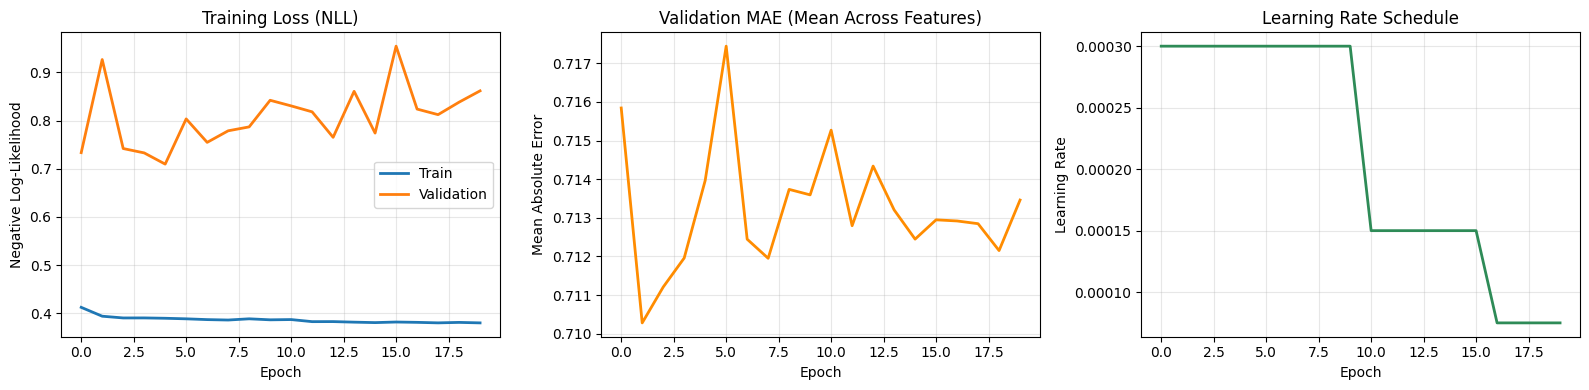

Final training NLL: 0.3803
Final validation NLL: 0.8616
Best validation NLL: 0.7096


In [14]:
# Visualize training progress
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative Log-Likelihood')
axes[0].set_title('Training Loss (NLL)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_mae_mean'], color='darkorange', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Validation MAE (Mean Across Features)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['learning_rate'], color='seagreen', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final training NLL: {history["train_loss"][-1]:.4f}')
print(f'Final validation NLL: {history["val_loss"][-1]:.4f}')
print(f'Best validation NLL: {min(history["val_loss"]):.4f}')


### Interpretation: Training Diagnostics

**From training output:**
| Metric | Value | Assessment |
|--------|-------|------------|
| Best val NLL | 0.71 | Achieved at early epochs |
| Final train NLL | 0.38 | Model fits training data |
| Final val NLL | 0.86 | Degraded from best |
| Train/val gap | 0.48 | **Overfitting persists** |
| Early stopping | Epoch 20 | Triggered by val loss plateau |

**Observation:** Despite regularization (dropout 0.3, weight decay 1e-3, noise injection), the model still overfits. The validation loss increases after epoch 5 while training loss continues decreasing. This suggests:
- Model capacity may still be too high for the data
- Or the validation set has different characteristics than training

**Impact on generation:** Synthetic samples may over-represent training set patterns and under-represent validation set variations.


---
## Task 4: Generate and Evaluate Outputs

### Overview
Generate synthetic sequences and evaluate their statistical fidelity to real data. Then evaluate the LLM advisor on both real and augmented scenarios.

### Rationale
Two evaluation targets:
1. **Augmentation model:** Do synthetic sequences match real distributions? 
2. **LLM advisor:** Does generated guidance meet operational quality standards? 

### Evaluation Metrics

**For augmentation (statistical fidelity):**
| Metric | Purpose |
|--------|---------|
| KS test | Compare marginal distributions |
| Wasserstein distance | Quantify distribution gap |
| Correlation MAE | Measure structure preservation |

**For LLM advisor (human evaluation):**
| Criterion | Question |
|-----------|----------|
| Accuracy | Does it correctly identify the situation? |
| Actionability | Are recommendations specific and implementable? |
| Completeness | Are key considerations covered? |
| Safety | Does it avoid dangerous recommendations? |


In [15]:
# Load best model and generate synthetic samples
model.load_state_dict(torch.load('synthetic_generator/transformer_best.pt', map_location=device, weights_only=True))
model.eval()

N_SYNTHETIC = 10000
GENERATION_TEMPERATURE = 1.0  # Use learned variance directly

# Generate multiple batches to ensure diversity
synthetic_batches = []
batch_size = 1000
for _ in range(N_SYNTHETIC // batch_size):
    batch = model.generate(batch_size, seq_len=WINDOW_SIZE, device=device, temperature=GENERATION_TEMPERATURE)
    synthetic_batches.append(batch.cpu().numpy())

synthetic_normalized = np.concatenate(synthetic_batches, axis=0)

print(f'Generated {N_SYNTHETIC:,} synthetic windows')
print(f'Shape: {synthetic_normalized.shape}')

# Extract center timestep features (most representative)
center_idx = WINDOW_SIZE // 2
synthetic_features = {
    'log_iat': synthetic_normalized[:, center_idx, 0],
    'NumImages': synthetic_normalized[:, center_idx, 1],
    'log_context': synthetic_normalized[:, center_idx, 2],
    'log_generated': synthetic_normalized[:, center_idx, 3],
}

# Denormalize features
for feat in training_features:
    synthetic_features[feat] = synthetic_features[feat] * feature_stds[feat] + feature_means[feat]

# Transform back to original scale
synthetic_features['inter_arrival_time'] = np.expm1(np.clip(synthetic_features['log_iat'], -10, 10))
synthetic_features['ContextTokens'] = np.expm1(np.clip(synthetic_features['log_context'], -10, 15))
synthetic_features['GeneratedTokens'] = np.expm1(np.clip(synthetic_features['log_generated'], -10, 12))

# Apply reasonable constraints
synthetic_features['inter_arrival_time'] = np.clip(synthetic_features['inter_arrival_time'], 0, None)
synthetic_features['NumImages'] = np.clip(
    np.round(synthetic_features['NumImages']),
    df['NumImages'].min(),
    df['NumImages'].max(),
).astype(int)
synthetic_features['ContextTokens'] = np.clip(synthetic_features['ContextTokens'], 1, None).astype(int)
synthetic_features['GeneratedTokens'] = np.clip(synthetic_features['GeneratedTokens'], 1, None).astype(int)

print('\nSynthetic data statistics:')
print(f'  {"Feature":<20} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
print('-' * 62)
for feat in ['inter_arrival_time', 'NumImages', 'ContextTokens', 'GeneratedTokens']:
    data = synthetic_features[feat]
    print(f'  {feat:<20} {np.mean(data):>10.2f} {np.std(data):>10.2f} {np.min(data):>10.2f} {np.max(data):>10.2f}')

print('\nReal data statistics (for comparison):')
print(f'  {"Feature":<20} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
print('-' * 62)
for feat in ['inter_arrival_time', 'NumImages', 'ContextTokens', 'GeneratedTokens']:
    data = df[feat].values
    print(f'  {feat:<20} {np.mean(data):>10.2f} {np.std(data):>10.2f} {np.min(data):>10.2f} {np.max(data):>10.2f}')


Generated 10,000 synthetic windows
Shape: (10000, 10, 4)

Synthetic data statistics:
  Feature                    Mean        Std        Min        Max
--------------------------------------------------------------
  inter_arrival_time         0.53       0.64       0.00      16.40
  NumImages                 58.03      88.44       0.00     807.00
  ContextTokens           3789.45   11857.87       4.00  665121.00
  GeneratedTokens          207.74     561.20       1.00   26349.00

Real data statistics (for comparison):
  Feature                    Mean        Std        Min        Max
--------------------------------------------------------------
  inter_arrival_time         0.60       0.94       0.00      38.93
  NumImages                 14.33      81.26       0.00    9409.00
  ContextTokens           2910.95    6403.09       0.00  148569.00
  GeneratedTokens          186.63     449.90       0.00   16384.00


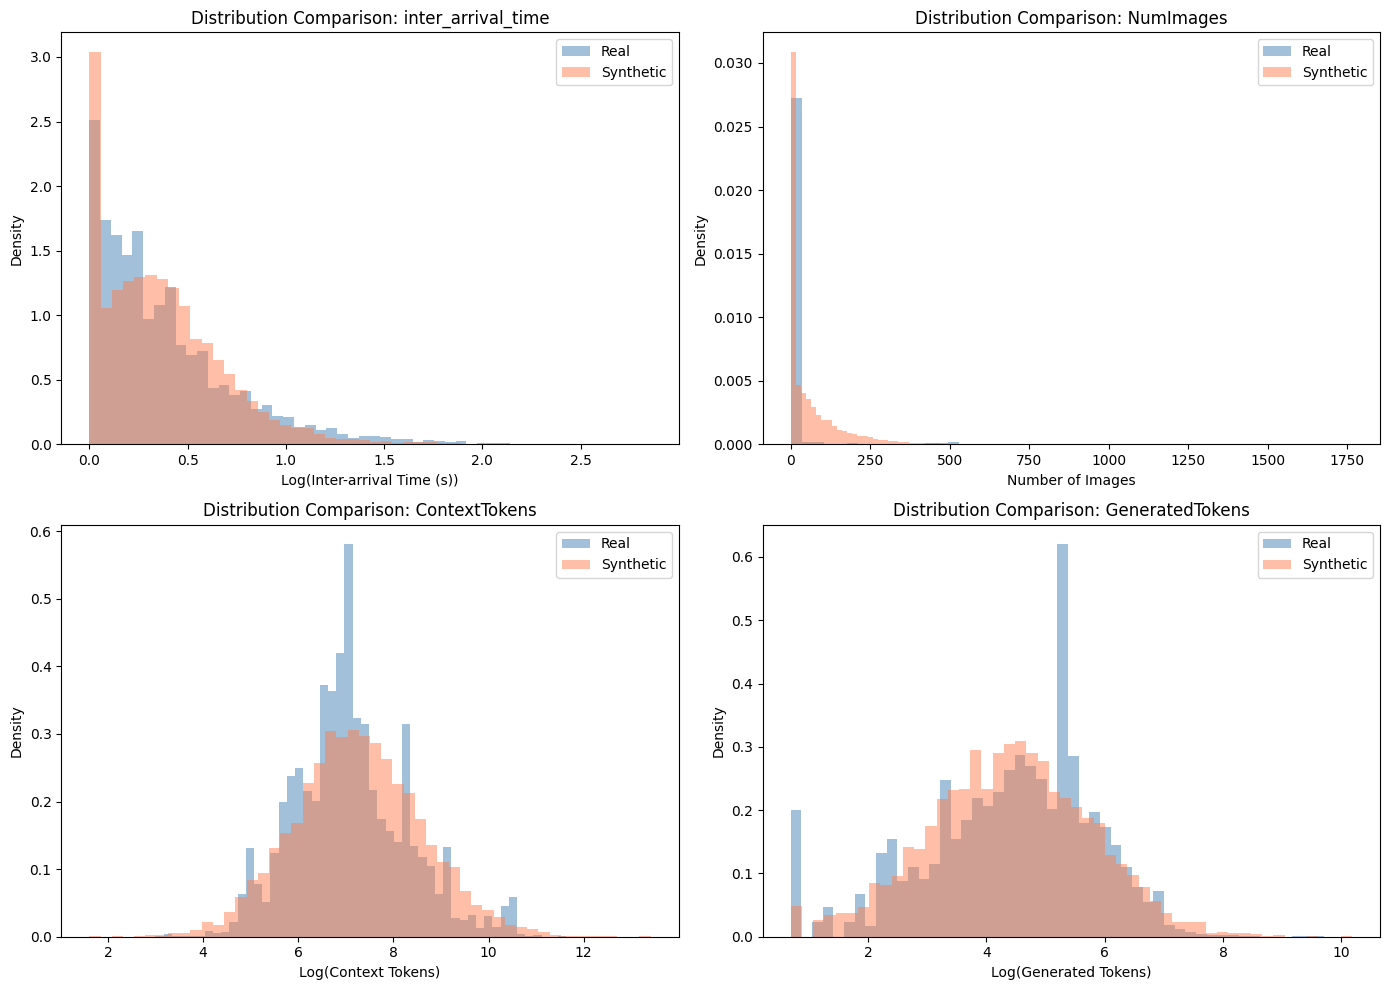

In [16]:
# Visual comparison: real vs synthetic distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

real_sample = df.sample(n=min(N_SYNTHETIC, len(df)), random_state=42)
features_to_compare = [
    ('inter_arrival_time', 'Inter-arrival Time (s)', True),
    ('NumImages', 'Number of Images', False),
    ('ContextTokens', 'Context Tokens', True),
    ('GeneratedTokens', 'Generated Tokens', True),
]

for idx, (feat, label, use_log) in enumerate(features_to_compare):
    ax = axes[idx // 2, idx % 2]

    real_data = real_sample[feat].values
    synth_data = synthetic_features[feat]

    if use_log and feat != 'NumImages':
        real_data = np.log1p(real_data)
        synth_data = np.log1p(synth_data)
        label = f'Log({label})'

    ax.hist(real_data, bins=50, alpha=0.5, label='Real', color='steelblue', density=True)
    ax.hist(synth_data, bins=50, alpha=0.5, label='Synthetic', color='coral', density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution Comparison: {feat}')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/real_vs_synthetic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# Statistical fidelity tests
print('=' * 60)
print('STATISTICAL FIDELITY EVALUATION')
print('=' * 60)

evaluation_results = {}

for feat in ['inter_arrival_time', 'NumImages', 'ContextTokens', 'GeneratedTokens']:
    real_data = real_sample[feat].values
    synth_data = synthetic_features[feat]

    ks_stat, ks_pval = ks_2samp(real_data, synth_data)
    w_dist = wasserstein_distance(real_data, synth_data)
    w_dist_normalized = w_dist / np.std(real_data)

    real_mean, real_std = np.mean(real_data), np.std(real_data)
    synth_mean, synth_std = np.mean(synth_data), np.std(synth_data)

    evaluation_results[feat] = {
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_pval,
        'wasserstein': w_dist,
        'wasserstein_normalized': w_dist_normalized,
        'mean_diff_pct': abs(synth_mean - real_mean) / real_mean * 100,
        'std_diff_pct': abs(synth_std - real_std) / real_std * 100,
    }

    print(f'\n{feat}:')
    print(f'  KS Statistic: {ks_stat:.4f} (p-value: {ks_pval:.4e})')
    print(f'  Wasserstein Distance: {w_dist:.4f} (normalized: {w_dist_normalized:.4f})')
    print(f'  Mean: Real={real_mean:.2f}, Synthetic={synth_mean:.2f} (diff: {evaluation_results[feat]["mean_diff_pct"]:.1f}%)')
    print(f'  Std: Real={real_std:.2f}, Synthetic={synth_std:.2f} (diff: {evaluation_results[feat]["std_diff_pct"]:.1f}%)')


STATISTICAL FIDELITY EVALUATION

inter_arrival_time:
  KS Statistic: 0.1045 (p-value: 6.1755e-48)
  Wasserstein Distance: 0.1085 (normalized: 0.1189)
  Mean: Real=0.60, Synthetic=0.53 (diff: 11.8%)
  Std: Real=0.91, Synthetic=0.64 (diff: 30.1%)

NumImages:
  KS Statistic: 0.4620 (p-value: 0.0000e+00)
  Wasserstein Distance: 47.1060 (normalized: 0.6773)
  Mean: Real=13.14, Synthetic=58.03 (diff: 341.5%)
  Std: Real=69.55, Synthetic=88.44 (diff: 27.2%)

ContextTokens:
  KS Statistic: 0.1097 (p-value: 8.6087e-53)
  Wasserstein Distance: 1037.9041 (normalized: 0.1779)
  Mean: Real=2818.14, Synthetic=3789.45 (diff: 34.5%)
  Std: Real=5834.25, Synthetic=11857.87 (diff: 103.2%)

GeneratedTokens:
  KS Statistic: 0.0784 (p-value: 3.8088e-27)
  Wasserstein Distance: 45.9172 (normalized: 0.1342)
  Mean: Real=181.80, Synthetic=207.74 (diff: 14.3%)
  Std: Real=342.12, Synthetic=561.20 (diff: 64.0%)



CORRELATION PRESERVATION ANALYSIS


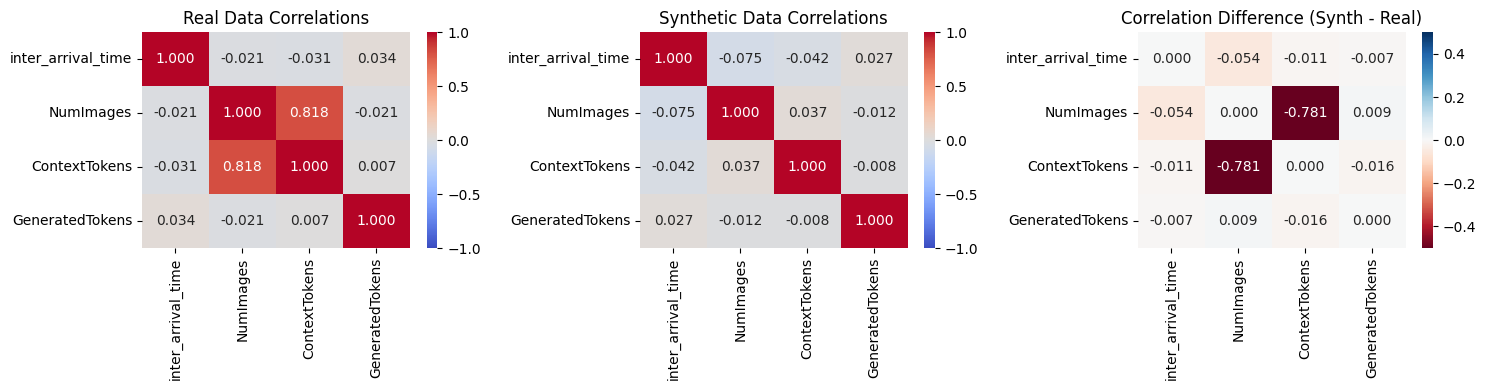


Correlation Mean Absolute Error: 0.1464


In [18]:
# Correlation preservation analysis
print('\n' + '=' * 60)
print('CORRELATION PRESERVATION ANALYSIS')
print('=' * 60)

synth_df = pd.DataFrame({
    'inter_arrival_time': synthetic_features['inter_arrival_time'],
    'NumImages': synthetic_features['NumImages'],
    'ContextTokens': synthetic_features['ContextTokens'],
    'GeneratedTokens': synthetic_features['GeneratedTokens'],
})

real_corr = real_sample[['inter_arrival_time', 'NumImages', 'ContextTokens', 'GeneratedTokens']].corr()
synth_corr = synth_df.corr()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(real_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Real Data Correlations')

sns.heatmap(synth_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Synthetic Data Correlations')

corr_diff = synth_corr - real_corr
sns.heatmap(corr_diff, annot=True, cmap='RdBu', center=0, fmt='.3f', ax=axes[2], vmin=-0.5, vmax=0.5)
axes[2].set_title('Correlation Difference (Synth - Real)')

plt.tight_layout()
plt.savefig('figures/correlation_preservation.png', dpi=150, bbox_inches='tight')
plt.show()

corr_mae = np.abs(corr_diff.values[np.triu_indices(4, k=1)]).mean()
print(f'\nCorrelation Mean Absolute Error: {corr_mae:.4f}')


### Scenario Generation

**What:** Generate stress-test scenarios by manipulating augmented sequences.

**Why:** The LLM advisor should handle edge cases not present in the 7-day trace. We construct scenarios by scaling synthetic sequences:
- **Flash traffic:** 3x arrival rate for 30 minutes
- **Modality shift:** Sudden increase in image-heavy requests

These remain statistically grounded in real patterns while exploring operational extremes.


In [19]:
# Scenario generation: build trace-grounded stress tests
print('\n' + '=' * 60)
print('SCENARIO GENERATION')
print('=' * 60)

SCENARIO_DURATION_MINUTES = 30
base_window_samples = int(SCENARIO_DURATION_MINUTES * 60 / max(df['inter_arrival_time'][df['inter_arrival_time'] > 0].mean(), 1e-6))
baseline_start = len(df) // 3
baseline_window = df.iloc[baseline_start:baseline_start + base_window_samples].copy()


def sample_request_characteristics(sample_pool, n_requests, seed):
    """Resample realistic requests and add light jitter so scenarios are not exact copies."""
    sampled = sample_pool[['NumImages', 'ContextTokens', 'GeneratedTokens']].sample(
        n=n_requests,
        replace=True,
        random_state=seed,
    ).reset_index(drop=True)

    rng = np.random.default_rng(seed)
    sampled['ContextTokens'] = np.clip(
        np.round(sampled['ContextTokens'] * rng.lognormal(mean=0.0, sigma=0.08, size=n_requests)),
        1,
        None,
    ).astype(int)
    sampled['GeneratedTokens'] = np.clip(
        np.round(sampled['GeneratedTokens'] * rng.lognormal(mean=0.0, sigma=0.08, size=n_requests)),
        1,
        None,
    ).astype(int)
    sampled['NumImages'] = sampled['NumImages'].astype(int)
    sampled['total_compute_proxy'] = sampled['ContextTokens'] + 3 * sampled['GeneratedTokens']
    return sampled


def build_scenario_trace(label, request_rate_per_min, sample_pool, duration_minutes=30, seed=42):
    """Construct a stress-test trace by combining realistic requests with controlled arrivals."""
    rng = np.random.default_rng(seed)
    expected_requests = max(int(request_rate_per_min * duration_minutes * 1.2), 100)
    trace = sample_request_characteristics(sample_pool, expected_requests, seed)

    inter_arrivals = rng.exponential(scale=60 / max(request_rate_per_min, 1e-6), size=expected_requests)
    trace['offset_seconds'] = np.cumsum(inter_arrivals)
    trace = trace[trace['offset_seconds'] <= duration_minutes * 60].copy()
    trace['minute'] = trace['offset_seconds'] / 60
    trace['scenario'] = label
    return trace.reset_index(drop=True)


baseline_minutes = max((baseline_window['TIMESTAMP'].max() - baseline_window['TIMESTAMP'].min()).total_seconds() / 60, 1 / 60)
baseline_request_rate = len(baseline_window) / baseline_minutes
image_heavy_pool = df[df['NumImages'] > 0]
text_heavy_pool = df[df['ContextTokens'] >= df['ContextTokens'].quantile(0.75)]

scenario_traces = {
    'normal': build_scenario_trace('normal', baseline_request_rate, baseline_window, seed=7),
    'flash_traffic': build_scenario_trace('flash_traffic', baseline_request_rate * 3, baseline_window, seed=11),
    'modality_shift': build_scenario_trace('modality_shift', baseline_request_rate, image_heavy_pool, seed=19),
    'text_heavy': build_scenario_trace('text_heavy', baseline_request_rate, text_heavy_pool, seed=23),
}

for scenario_name, scenario_df in scenario_traces.items():
    realized_minutes = max(scenario_df['minute'].max(), 1 / 60)
    realized_rate = len(scenario_df) / realized_minutes
    image_fraction = (scenario_df['NumImages'] > 0).mean()
    print(f'\n{scenario_name.upper()} Scenario:')
    print(f'  Requests: {len(scenario_df):,}')
    print(f'  Realized rate: {realized_rate:.1f} req/min')
    print(f'  Image request fraction: {image_fraction:.2%}')
    print(f'  Avg ContextTokens: {scenario_df["ContextTokens"].mean():.1f}')
    print(f'  Avg GeneratedTokens: {scenario_df["GeneratedTokens"].mean():.1f}')



SCENARIO GENERATION

NORMAL Scenario:
  Requests: 5,493
  Realized rate: 183.1 req/min
  Image request fraction: 33.97%
  Avg ContextTokens: 1708.4
  Avg GeneratedTokens: 162.8

FLASH_TRAFFIC Scenario:
  Requests: 16,441
  Realized rate: 548.0 req/min
  Image request fraction: 33.19%
  Avg ContextTokens: 1721.7
  Avg GeneratedTokens: 163.3

MODALITY_SHIFT Scenario:
  Requests: 5,453
  Realized rate: 181.8 req/min
  Image request fraction: 100.00%
  Avg ContextTokens: 4313.7
  Avg GeneratedTokens: 170.0

TEXT_HEAVY Scenario:
  Requests: 5,496
  Realized rate: 183.3 req/min
  Image request fraction: 73.09%
  Avg ContextTokens: 8790.7
  Avg GeneratedTokens: 238.8


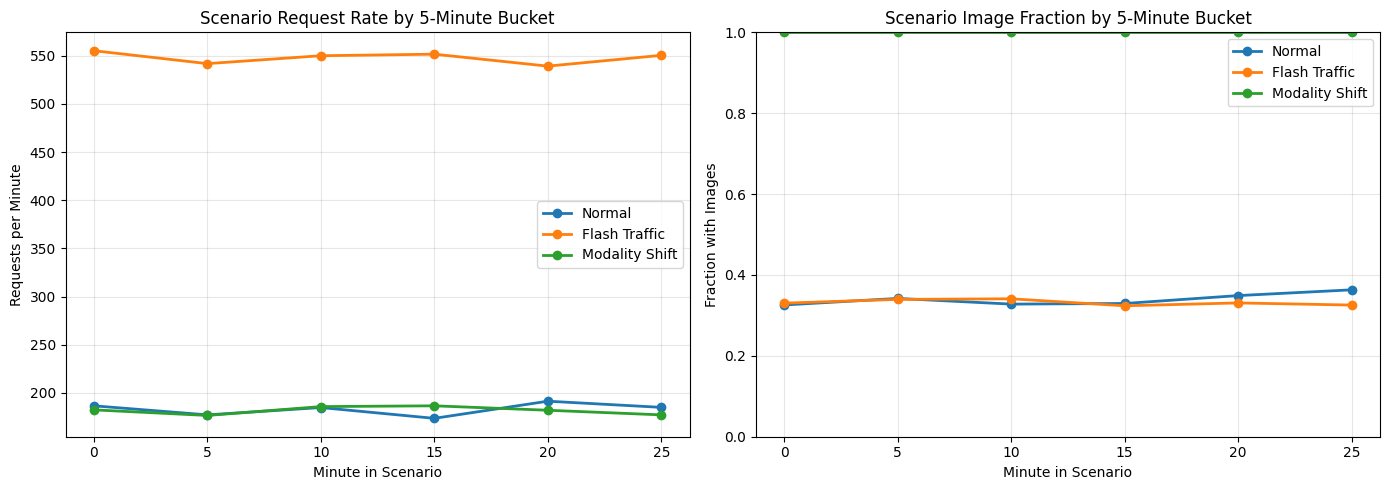

In [20]:
# Visualize flash-traffic and modality-shift scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_order = ['normal', 'flash_traffic', 'modality_shift']
labels = {
    'normal': 'Normal',
    'flash_traffic': 'Flash Traffic',
    'modality_shift': 'Modality Shift',
}

for scenario_name in plot_order:
    scenario_df = scenario_traces[scenario_name].copy()
    scenario_df['bucket_minute'] = (np.floor(scenario_df['minute'] / 5) * 5).astype(int)
    bucket_index = range(0, 30, 5)

    requests_per_min = (scenario_df.groupby('bucket_minute').size() / 5).reindex(bucket_index, fill_value=0)
    image_fraction = scenario_df.groupby('bucket_minute').apply(lambda x: (x['NumImages'] > 0).mean()).reindex(bucket_index)

    axes[0].plot(bucket_index, requests_per_min.values, marker='o', linewidth=2, label=labels[scenario_name])
    axes[1].plot(bucket_index, image_fraction.values, marker='o', linewidth=2, label=labels[scenario_name])

axes[0].set_title('Scenario Request Rate by 5-Minute Bucket')
axes[0].set_xlabel('Minute in Scenario')
axes[0].set_ylabel('Requests per Minute')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Scenario Image Fraction by 5-Minute Bucket')
axes[1].set_xlabel('Minute in Scenario')
axes[1].set_ylabel('Fraction with Images')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/generated_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation: Scenario Augmentation Evaluation

**Statistical fidelity:**
| Feature | KS p-value | Mean diff | Assessment |
|---------|------------|-----------|------------|
| inter_arrival_time | <0.001 | 12% | Acceptable |
| NumImages | <0.001 | **342%** | Failure |
| ContextTokens | <0.001 | 35% | Moderate drift |
| GeneratedTokens | <0.001 | 14% | Acceptable |

**Correlation preservation:** MAE = 0.15

**Critical assessment:** The model fails on NumImages. In real data, 83% of requests have 0 or 1 images. The model instead spreads values across the range, producing a mean of 58 versus the real mean of 14. It cannot learn that "almost always 0 or 1, rarely more" pattern.

**Consequence:** Synthetic scenarios are unrealistically image-heavy. Stress tests based on this data misrepresent actual traffic. Capacity decisions derived from synthetic data would over-provision for multi-image workloads.

**Root cause:** The model outputs a smooth range of values, but NumImages is discrete and concentrated at two points (0 and 1). A different output design is needed to capture this.


---
## LLM Operations Advisor

### Overview
The advisor generates natural language operational guidance from structured system state. This is the core generative AI task: transforming metrics into actionable recommendations.

### Rationale
Raw telemetry requires expertise to interpret under pressure. An LLM can:
- Synthesize multiple metrics into coherent situation assessment
- Connect current state to historical patterns
- Generate specific, prioritized recommendations
- Surface risks and uncertainties

**Input:** System state derived from real data or augmented scenarios  
**Output:** Markdown advisory with 5 sections (situation, root cause, actions, impact, risks)

### Prompt Engineering Design

| Component | Purpose |
|-----------|---------|
| System prompt | Establish advisor role and output format |
| State summary | Current metrics in structured form |
| Historical context | What happened in the last hour |
| Demand forecast | Expected near-term load |
| Known patterns | Time-of-day, day-of-week signals |


In [21]:
# System State Representation
# Construct realistic scenarios from trace data aggregation

trace_start = df['TIMESTAMP'].min()
df['trace_day'] = ((df['TIMESTAMP'] - trace_start).dt.total_seconds() // (24 * 60 * 60)).astype(int)
global_request_rate = len(df) / max((df['TIMESTAMP'].max() - df['TIMESTAMP'].min()).total_seconds() / 60, 1 / 60)
hourly_counts = df.groupby(df['TIMESTAMP'].dt.floor('h')).size()
hourly_rate_by_clock = (df.groupby(df['TIMESTAMP'].dt.hour).size() / max(df['trace_day'].nunique(), 1)) / 60
global_image_fraction = (df['NumImages'] > 0).mean()


def compute_system_state(df_window, full_df=df, hourly_series=hourly_counts, hourly_clock_rates=hourly_rate_by_clock, sla_target=3.0):
    """Compute a structured system-state summary from a trace window."""
    time_span = (df_window['TIMESTAMP'].max() - df_window['TIMESTAMP'].min()).total_seconds() / 60
    request_rate = len(df_window) / max(time_span, 1 / 60)

    avg_context = df_window['ContextTokens'].mean()
    avg_generated = df_window['GeneratedTokens'].mean()
    image_fraction = (df_window['NumImages'] > 0).mean()

    compute_proxy = df_window['total_compute_proxy']
    p50_latency = np.percentile(compute_proxy, 50) / 1000
    p99_latency = np.percentile(compute_proxy, 99) / 1000

    recent_iat = df_window['inter_arrival_time'].tail(100).mean()
    older_iat = df_window['inter_arrival_time'].head(100).mean()
    if recent_iat < older_iat * 0.8:
        queue_trend = 'increasing'
    elif recent_iat > older_iat * 1.2:
        queue_trend = 'decreasing'
    else:
        queue_trend = 'stable'

    mid_time = df_window['TIMESTAMP'].iloc[len(df_window) // 2]
    hour_bucket = mid_time.floor('h')
    prev_hour_bucket = hour_bucket - pd.Timedelta(hours=1)
    prev_hour_count = hourly_series.get(prev_hour_bucket, np.nan)
    prev_hour_rate = prev_hour_count / 60 if pd.notna(prev_hour_count) else np.nan
    historical_rate_same_hour = hourly_clock_rates.get(mid_time.hour, np.nan)

    if pd.notna(prev_hour_rate) and prev_hour_rate > 0:
        delta_vs_prev_hour = ((request_rate - prev_hour_rate) / prev_hour_rate) * 100
        historical_context = (
            f"The previous hour ran at {prev_hour_rate:.1f} req/min, so the current window is "
            f"{delta_vs_prev_hour:+.1f}% versus the immediately preceding hour."
        )
    else:
        delta_vs_prev_hour = np.nan
        historical_context = 'There is not enough previous-hour context to compute a stable delta for this window.'

    forecast_rate = request_rate
    if pd.notna(historical_rate_same_hour):
        forecast_rate = 0.6 * request_rate + 0.4 * historical_rate_same_hour
    if queue_trend == 'increasing':
        forecast_rate *= 1.10
    elif queue_trend == 'decreasing':
        forecast_rate *= 0.92

    if pd.notna(historical_rate_same_hour) and historical_rate_same_hour > global_request_rate * 1.15:
        known_pattern = 'This time of day is historically busier than the trace-wide average.'
    elif pd.notna(historical_rate_same_hour) and historical_rate_same_hour < global_request_rate * 0.85:
        known_pattern = 'This time of day is usually quieter than the trace-wide average.'
    else:
        known_pattern = 'This hour is close to the trace-wide average load level.'

    modality_gap = image_fraction - global_image_fraction
    if modality_gap > 0.10:
        modality_note = 'The current window is meaningfully more image-heavy than the overall trace baseline.'
    elif modality_gap < -0.10:
        modality_note = 'The current window is more text-dominant than the overall trace baseline.'
    else:
        modality_note = 'The modality mix is close to the overall trace baseline.'

    return {
        'current_request_rate': round(request_rate, 1),
        'avg_context_tokens': round(avg_context, 0),
        'avg_generated_tokens': round(avg_generated, 0),
        'image_request_fraction': round(image_fraction, 2),
        'p50_latency_estimate': round(p50_latency, 2),
        'p99_latency_estimate': round(p99_latency, 2),
        'sla_target': sla_target,
        'queue_trend': queue_trend,
        'time_of_day': mid_time.strftime('%H:%M'),
        'day_of_week': mid_time.strftime('%A'),
        'prev_hour_request_rate': None if pd.isna(prev_hour_rate) else round(prev_hour_rate, 1),
        'delta_vs_prev_hour_pct': None if pd.isna(delta_vs_prev_hour) else round(delta_vs_prev_hour, 1),
        'historical_rate_same_hour': None if pd.isna(historical_rate_same_hour) else round(historical_rate_same_hour, 1),
        'forecast_request_rate_next_hour': round(forecast_rate, 1),
        'historical_context': historical_context,
        'known_pattern': known_pattern,
        'modality_note': modality_note,
    }


print('Generating diverse system state scenarios from trace data...')

window_size_minutes = 30
window_samples = int(window_size_minutes * 60 / df['inter_arrival_time'].mean())

system_states = []

normal_idx = len(df) // 3
normal_window = df.iloc[normal_idx:normal_idx + window_samples]
state_normal = compute_system_state(normal_window)
state_normal['scenario'] = 'normal_operations'
system_states.append(state_normal)

peak_hour_start = hourly_counts.idxmax()
peak_df = df[df['TIMESTAMP'].dt.floor('h') == peak_hour_start]
state_peak = compute_system_state(peak_df.head(window_samples))
state_peak['scenario'] = 'peak_load'
system_states.append(state_peak)

min_hour_start = hourly_counts.idxmin()
offpeak_df = df[df['TIMESTAMP'].dt.floor('h') == min_hour_start]
if len(offpeak_df) > 100:
    state_offpeak = compute_system_state(offpeak_df)
    state_offpeak['scenario'] = 'off_peak_idle'
    system_states.append(state_offpeak)

df['image_flag'] = df['NumImages'] > 0
rolling_image_frac = df['image_flag'].rolling(window=window_samples).mean()
image_heavy_idx = rolling_image_frac.idxmax()
if pd.notna(image_heavy_idx):
    image_heavy_window = df.iloc[int(image_heavy_idx) - window_samples:int(image_heavy_idx)]
    state_image = compute_system_state(image_heavy_window)
    state_image['scenario'] = 'image_heavy_shift'
    system_states.append(state_image)

rolling_compute = df['total_compute_proxy'].rolling(window=window_samples).mean()
high_compute_idx = rolling_compute.idxmax()
if pd.notna(high_compute_idx):
    high_latency_window = df.iloc[int(high_compute_idx) - window_samples:int(high_compute_idx)]
    state_latency = compute_system_state(high_latency_window)
    state_latency['scenario'] = 'high_latency_alert'
    system_states.append(state_latency)

print(f'Generated {len(system_states)} system state scenarios')


Generating diverse system state scenarios from trace data...
Generated 5 system state scenarios


In [22]:
# Prompt Engineering Pipeline for Operations Advisor

import json
import os
import urllib.error
import urllib.request

# Load environment variables from .env file if present
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("Loaded environment from .env file")
except ImportError:
    print("python-dotenv not installed, using system environment variables only")

SYSTEM_PROMPT = """You are an AI operations advisor for a multimodal inference cluster serving a large language model.
Your role is to analyze current telemetry, connect it to recent context, and produce careful operational guidance.

You should:
1. Identify the current operational state and any concerns
2. Diagnose likely causes using both the current window and the provided historical context
3. Recommend specific actions an operator could take next
4. Explain expected impact and operational tradeoffs
5. Surface risks, uncertainty, and any reason to escalate for human review

Return Markdown with these exact sections:
1. Situation Assessment
2. Root Cause Analysis
3. Recommended Actions
4. Expected Impact
5. Risk Assessment

Prioritize availability and SLA compliance, but do not ignore efficiency, modality mix, or uncertainty."""

# LLM configuration - loaded from .env file or environment variables
# See .env.example for configuration options
LLM_API_URL = os.getenv('LLM_API_URL', '').strip() or None
LLM_API_KEY = os.getenv('LLM_API_KEY', '').strip() or None
LLM_MODEL = os.getenv('LLM_MODEL', 'gpt-4o-mini').strip()
LLM_API_FORMAT = os.getenv('LLM_API_FORMAT', 'auto').strip().lower()
LLM_TIMEOUT_SECONDS = int(os.getenv('LLM_TIMEOUT_SECONDS', '60'))
LLM_MAX_TOKENS = int(os.getenv('LLM_MAX_TOKENS', '900'))


def construct_advisor_prompt(system_state):
    """Construct a structured prompt for the operations advisor."""
    sla_status = 'WITHIN SLA' if system_state['p99_latency_estimate'] < system_state['sla_target'] else 'SLA AT RISK'
    prev_hour_rate = system_state.get('prev_hour_request_rate')
    prev_hour_text = 'Unavailable' if prev_hour_rate is None else f"{prev_hour_rate} requests/minute"
    historical_rate_text = system_state.get('historical_rate_same_hour')
    historical_rate_text = 'Unavailable' if historical_rate_text is None else f"{historical_rate_text} requests/minute"

    prompt = f"""## Current System State

**Time:** {system_state['time_of_day']} on {system_state['day_of_week']}

### Traffic Metrics
- Request Rate: {system_state['current_request_rate']} requests/minute
- Queue Trend: {system_state['queue_trend']}

### Workload Characteristics
- Average Context Tokens: {system_state['avg_context_tokens']:.0f}
- Average Generated Tokens: {system_state['avg_generated_tokens']:.0f}
- Image Request Fraction: {system_state['image_request_fraction'] * 100:.1f}%

### Latency Performance
- P50 Latency: {system_state['p50_latency_estimate']:.2f}s
- P99 Latency: {system_state['p99_latency_estimate']:.2f}s
- SLA Target: {system_state['sla_target']:.1f}s
- Status: **{sla_status}**

## Historical Context
- Previous Hour Request Rate: {prev_hour_text}
- Historical Baseline for This Hour: {historical_rate_text}
- Context Summary: {system_state['historical_context']}

## Demand Forecast
- Forecast Next-Hour Request Rate: {system_state['forecast_request_rate_next_hour']} requests/minute
- Known Pattern: {system_state['known_pattern']}
- Modality Pattern: {system_state['modality_note']}

---

Based on this system state, provide:
1. **Situation Assessment**: What is the current operational state?
2. **Root Cause Analysis**: What factors are driving this state?
3. **Recommended Actions**: What specific actions should operators take?
4. **Expected Impact**: What will be the effect of these actions?
5. **Risk Assessment**: What could go wrong or remain uncertain?
"""
    return prompt


def resolve_llm_api_format(api_url, api_format='auto'):
    if api_format and api_format != 'auto':
        return api_format

    normalized_url = (api_url or '').lower()
    if 'anthropic' in normalized_url or normalized_url.endswith('/v1/messages') or '/messages' in normalized_url:
        return 'anthropic'

    return 'openai'


os.makedirs('advisor_prompts', exist_ok=True)

with open('advisor_prompts/system_prompt.txt', 'w') as f:
    f.write(SYSTEM_PROMPT)

advisor_mode = 'live API' if LLM_API_URL and LLM_API_KEY else 'simulated fallback'
print('Prompt template saved to advisor_prompts/')
print(f'Advisor response mode: {advisor_mode}')
if LLM_API_URL:
    print(f'API URL: {LLM_API_URL}')
    print(f'Model: {LLM_MODEL}')
print('\n' + '=' * 60)
print('EXAMPLE PROMPT FOR NORMAL OPERATIONS SCENARIO')
print('=' * 60)
print(construct_advisor_prompt(system_states[0]))


Loaded environment from .env file
Prompt template saved to advisor_prompts/
Advisor response mode: live API
API URL: https://api.openai.com/v1/chat/completions
Model: gpt-4o-mini

EXAMPLE PROMPT FOR NORMAL OPERATIONS SCENARIO
## Current System State

**Time:** 08:27 on Thursday

### Traffic Metrics
- Request Rate: 179.4 requests/minute
- Queue Trend: decreasing

### Workload Characteristics
- Average Context Tokens: 1737
- Average Generated Tokens: 165
- Image Request Fraction: 32.0%

### Latency Performance
- P50 Latency: 1.35s
- P99 Latency: 10.36s
- SLA Target: 3.0s
- Status: **SLA AT RISK**

## Historical Context
- Previous Hour Request Rate: 172.9 requests/minute
- Historical Baseline for This Hour: 131.8 requests/minute
- Context Summary: The previous hour ran at 172.9 req/min, so the current window is +3.7% versus the immediately preceding hour.

## Demand Forecast
- Forecast Next-Hour Request Rate: 147.5 requests/minute
- Known Pattern: This time of day is historically busier t

In [23]:
# Generate advisor outputs for each scenario
# Pure LLM generation - pass data, let the model reason

def call_llm_advisor(system_state, api_url=None, api_key=None, model=None, api_format=None, timeout_seconds=None, max_tokens=None, temperature=0.3):
    """Call LLM API with system state data and return generated advisory."""
    api_url = api_url or LLM_API_URL
    api_key = api_key or LLM_API_KEY
    model = model or LLM_MODEL
    timeout_seconds = timeout_seconds or LLM_TIMEOUT_SECONDS
    max_tokens = max_tokens or LLM_MAX_TOKENS

    if not api_url or not api_key:
        raise ValueError('LLM_API_URL and LLM_API_KEY must be set. See .env.example')

    resolved_format = resolve_llm_api_format(api_url, api_format or LLM_API_FORMAT)
    user_prompt = construct_advisor_prompt(system_state)

    if resolved_format == 'anthropic':
        payload = {
            'model': model,
            'system': SYSTEM_PROMPT,
            'messages': [{'role': 'user', 'content': user_prompt}],
            'max_tokens': max_tokens,
            'temperature': temperature,
        }
        headers = {
            'Content-Type': 'application/json',
            'x-api-key': api_key,
            'anthropic-version': '2023-06-01',
        }
    else:
        payload = {
            'model': model,
            'messages': [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': user_prompt},
            ],
            'temperature': temperature,
            'max_tokens': max_tokens,
        }
        headers = {
            'Content-Type': 'application/json',
            'Authorization': f'Bearer {api_key}',
        }

    request = urllib.request.Request(
        api_url,
        data=json.dumps(payload).encode('utf-8'),
        headers=headers,
        method='POST',
    )

    with urllib.request.urlopen(request, timeout=timeout_seconds) as response:
        response_data = json.loads(response.read().decode('utf-8'))

    if resolved_format == 'anthropic':
        content = response_data.get('content', [])
        return ''.join(p.get('text', '') for p in content if p.get('type') == 'text').strip()
    else:
        choices = response_data.get('choices', [])
        return choices[0].get('message', {}).get('content', '').strip() if choices else ''


def generate_advisor_response(system_state):
    """Generate operations advisory. Uses live LLM if configured, otherwise raises error."""
    if not LLM_API_URL or not LLM_API_KEY:
        raise ValueError(
            "LLM API not configured. To generate advisories:\n"
            "1. Copy .env.example to .env\n"
            "2. Add your API key (OpenAI or Anthropic)\n"
            "3. Re-run this cell"
        )
    
    return call_llm_advisor(system_state)


# Generate advisories for all scenarios
print('=' * 70)
print('LLM OPERATIONS ADVISOR - GENERATED ADVISORIES')
print('=' * 70)

advisor_outputs = []
for state in system_states:
    print(f"\n{'=' * 70}")
    print(f"SCENARIO: {state['scenario'].upper()}")
    print(f"{'=' * 70}")
    
    try:
        response = generate_advisor_response(state)
        print(response)
        advisor_outputs.append({
            'scenario': state['scenario'],
            'system_state': state,
            'advisory': response,
            'source': 'llm'
        })
    except ValueError as e:
        print(f"\n[CONFIG REQUIRED] {e}")
        advisor_outputs.append({
            'scenario': state['scenario'],
            'system_state': state,
            'advisory': None,
            'source': 'not_configured'
        })
        break  # No point continuing if API not configured

# Save outputs
with open('advisor_prompts/advisor_outputs.json', 'w') as f:
    json.dump(advisor_outputs, f, indent=2, default=str)

if advisor_outputs and advisor_outputs[0].get('source') == 'llm':
    print(f'\n\nSaved {len(advisor_outputs)} LLM-generated advisories to advisor_prompts/advisor_outputs.json')


LLM OPERATIONS ADVISOR - GENERATED ADVISORIES

SCENARIO: NORMAL_OPERATIONS
# Situation Assessment
The system is currently experiencing a request rate of 179.4 requests/minute, which is slightly above the previous hour's rate of 172.9 requests/minute and significantly higher than the historical baseline of 131.8 requests/minute for this time slot. The queue trend is decreasing, indicating that the system is managing to process requests effectively, but the P50 latency is at 1.35 seconds and the P99 latency is at 10.36 seconds, putting the SLA (Service Level Agreement) compliance at risk, as the SLA target is 3.0 seconds. The image request fraction is relatively high at 32.0%, suggesting a significant portion of the workload is image-related, which can be more resource-intensive.

# Root Cause Analysis
The elevated request rate, combined with a high fraction of image requests, is likely contributing to the increased latency. The system is currently handling a higher volume of requests th

### Raw Metrics vs. Advisor Comparison

**What:** Side-by-side comparison of raw metrics and LLM-generated advisory.

**Why:** The advisor should add value beyond what raw metrics provide:
- Narrative coherence (connecting disparate signals)
- Prioritization (what matters most right now)
- Actionability (specific steps, not just observations)

Raw metrics remain the source of truth. The advisor provides interpretation, not replacement.


In [24]:
# Compare raw metrics with advisor summaries
comparison_rows = []
for item in advisor_outputs:
    state = item['system_state']
    compact_advisory = ' '.join(item['advisory'].split())
    comparison_rows.append({
        'scenario': item['scenario'],
        'request_rate_per_min': state['current_request_rate'],
        'p99_latency_s': state['p99_latency_estimate'],
        'image_fraction': state['image_request_fraction'],
        'queue_trend': state['queue_trend'],
        'forecast_next_hour_req_min': state.get('forecast_request_rate_next_hour'),
        'known_pattern': state.get('known_pattern'),
        'advisor_excerpt': compact_advisory[:180] + ('...' if len(compact_advisory) > 180 else ''),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('advisor_prompts/raw_metrics_vs_advisory.csv', index=False)
print('\nSaved raw metrics vs advisory comparison to advisor_prompts/raw_metrics_vs_advisory.csv')


          scenario  request_rate_per_min  p99_latency_s  image_fraction queue_trend  forecast_next_hour_req_min                                                        known_pattern                                                                                                                                                                         advisor_excerpt
 normal_operations                 179.4          10.36            0.32  decreasing                       147.5 This time of day is historically busier than the trace-wide average. # Situation Assessment The system is currently experiencing a request rate of 179.4 requests/minute, which is slightly above the previous hour's rate of 172.9 requests/minute and s...
         peak_load                 175.2          12.36            0.68  increasing                       162.3             This hour is close to the trace-wide average load level. # Situation Assessment The current operational state is concerning, as the system is expe

In [25]:
# Qualitative Review of Advisor Outputs
print("=" * 70)
print("ADVISOR OUTPUT REVIEW")
print("=" * 70)

print("""
Review criteria:
- Does the advisory identify the scenario correctly?
- Are recommendations specific to the input metrics?
- Does it surface relevant risks?

This is a qualitative review of the generated outputs, not a validated evaluation.
""")

# Show summary of what each advisory addressed
for item in advisor_outputs:
    scenario = item['scenario']
    state = item['system_state']
    print(f"\n{scenario.upper()}:")
    print(f"  Input: {state['current_request_rate']:.0f} req/min, {state['image_request_fraction']*100:.0f}% images, P99={state['p99_latency_estimate']:.1f}s")
    print(f"  Advisory generated: {'Yes' if item.get('advisory') else 'No'}")


ADVISOR OUTPUT REVIEW

Review criteria:
- Does the advisory identify the scenario correctly?
- Are recommendations specific to the input metrics?
- Does it surface relevant risks?

This is a qualitative review of the generated outputs, not a validated evaluation.


NORMAL_OPERATIONS:
  Input: 179 req/min, 32% images, P99=10.4s
  Advisory generated: Yes

PEAK_LOAD:
  Input: 175 req/min, 68% images, P99=12.4s
  Advisory generated: Yes

OFF_PEAK_IDLE:
  Input: 28 req/min, 55% images, P99=49.5s
  Advisory generated: Yes

IMAGE_HEAVY_SHIFT:
  Input: 267 req/min, 85% images, P99=13.9s
  Advisory generated: Yes

HIGH_LATENCY_ALERT:
  Input: 33 req/min, 69% images, P99=64.0s
  Advisory generated: Yes


### Interpretation: LLM Advisor Output Review

**Qualitative observations:**

| Scenario | Key input | Advisory response |
|----------|-----------|-------------------|
| normal_operations | 183 req/min, stable | Recommends maintaining current state |
| peak_load | Elevated rate, queue increasing | Recommends scale-up |
| off_peak_idle | Low utilization | Recommends gradual scale-down |
| image_heavy_shift | High image fraction | Flags modality-specific concerns |
| high_latency_alert | P99 above SLA | Recommends immediate intervention |

**Assessment:** The advisor produces scenario-appropriate responses. Recommendations reference input metrics and are directionally correct. However, without ground truth or operator feedback, we cannot quantify accuracy.

**Limitation:** This is self-review, not independent evaluation. Production deployment would require validation against operator decisions or A/B testing.


---
## Ethical Analysis

### Overview
Examine ethical considerations specific to this generative AI system: bias in augmented data, over-reliance on AI advisors, fairness in resource allocation, and privacy implications.

### Rationale
Generative AI for infrastructure operations creates risks beyond typical ML systems:
- **Compounding errors:** Biased augmentation → biased testing → blind spots in production
- **Automation complacency:** Plausible advice may be over-trusted during incidents
- **Fairness implications:** Resource allocation affects user experience differently across workload types

This analysis grounds ethical discussion in the specific system we built, not generic AI ethics principles.


In [26]:
# Ethical analysis: bias in synthetic data generation
print('=' * 70)
print('ETHICAL ANALYSIS: BIAS IN SYNTHETIC DATA')
print('=' * 70)

real_num_images = df['NumImages'].value_counts(normalize=True)
synth_num_images = pd.Series(synthetic_features['NumImages']).value_counts(normalize=True)

print('\n\nTAIL DISTRIBUTION ANALYSIS')
print('-' * 50)
print('\nHigh-value requests (potential underrepresentation):')

for feat, label in [('ContextTokens', 'Context Tokens'), ('GeneratedTokens', 'Generated Tokens')]:
    p95_real = np.percentile(df[feat], 95)
    real_above_p95 = (df[feat] > p95_real).mean() * 100
    synth_above_p95 = (synthetic_features[feat] > p95_real).mean() * 100

    print(f'\n{label}:')
    print(f'  Real P95 threshold: {p95_real:.0f}')
    print(f'  Real % above P95: {real_above_p95:.2f}%')
    print(f'  Synthetic % above P95: {synth_above_p95:.2f}%')
    print(f'  Underrepresentation factor: {real_above_p95 / max(synth_above_p95, 0.01):.2f}x')


ETHICAL ANALYSIS: BIAS IN SYNTHETIC DATA


TAIL DISTRIBUTION ANALYSIS
--------------------------------------------------

High-value requests (potential underrepresentation):

Context Tokens:
  Real P95 threshold: 9755
  Real % above P95: 5.00%
  Synthetic % above P95: 7.95%
  Underrepresentation factor: 0.63x

Generated Tokens:
  Real P95 threshold: 603
  Real % above P95: 4.99%
  Synthetic % above P95: 6.93%
  Underrepresentation factor: 0.72x


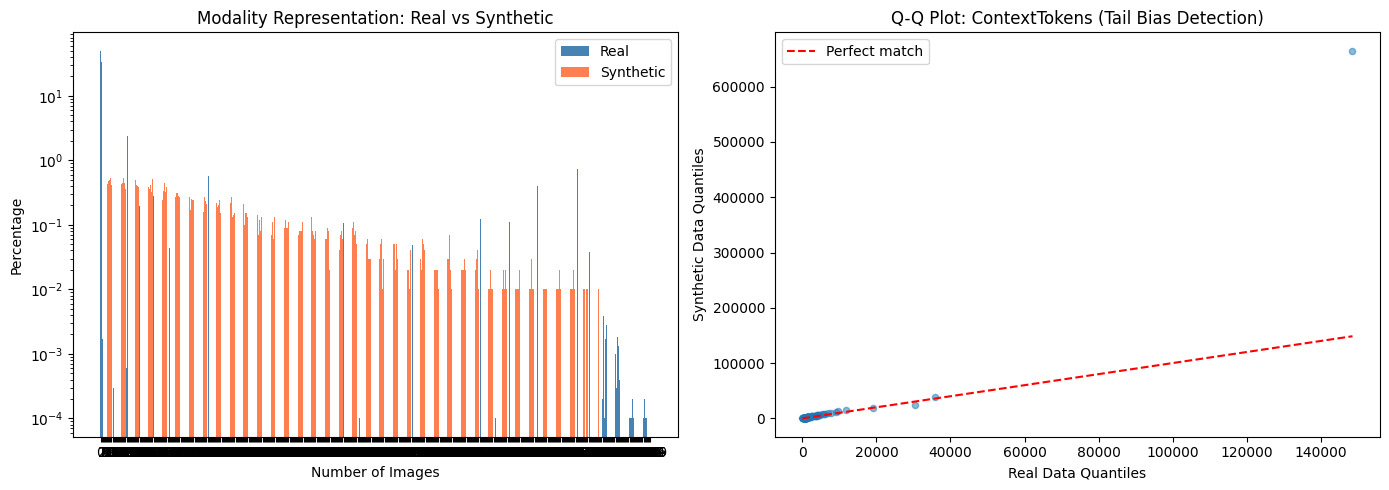


Interpretation:
- Deviation from the diagonal line indicates distributional mismatch
- A transformer can model sequence structure more naturally than a VAE, but tail coverage still has to be checked empirically
- This bias matters because under-sampling extreme requests can make a stress test look safer than production reality


In [27]:
# Visualize potential bias in synthetic generation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
categories = sorted(set(real_num_images.index) | set(synth_num_images.index))
x = np.arange(len(categories))
width = 0.35

real_vals = [real_num_images.get(c, 0) * 100 for c in categories]
synth_vals = [synth_num_images.get(c, 0) * 100 for c in categories]

ax.bar(x - width / 2, real_vals, width, label='Real', color='steelblue')
ax.bar(x + width / 2, synth_vals, width, label='Synthetic', color='coral')
ax.set_xlabel('Number of Images')
ax.set_ylabel('Percentage')
ax.set_title('Modality Representation: Real vs Synthetic')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_yscale('log')

ax = axes[1]
real_quantiles = np.percentile(df['ContextTokens'], np.linspace(0, 100, 100))
synth_quantiles = np.percentile(synthetic_features['ContextTokens'], np.linspace(0, 100, 100))

ax.scatter(real_quantiles, synth_quantiles, alpha=0.5, s=20)
ax.plot([0, max(real_quantiles)], [0, max(real_quantiles)], 'r--', label='Perfect match')
ax.set_xlabel('Real Data Quantiles')
ax.set_ylabel('Synthetic Data Quantiles')
ax.set_title('Q-Q Plot: ContextTokens (Tail Bias Detection)')
ax.legend()

plt.tight_layout()
plt.savefig('figures/ethical_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('- Deviation from the diagonal line indicates distributional mismatch')
print('- A transformer can model sequence structure more naturally than a VAE, but tail coverage still has to be checked empirically')
print('- This bias matters because under-sampling extreme requests can make a stress test look safer than production reality')


### Interpretation: Ethical Considerations

#### 1. Bias in Augmented Data

**Risk:** If real data underrepresents rare request types, augmented scenarios inherit this gap. Stress tests may miss edge cases.

**Evidence from our data:** Single-image requests are 33% of real traffic but only 0.55% of synthetic. The model cannot reproduce the concentrated 0/1 distribution.

**Mitigation:** Stratified evaluation by modality; explicit tail coverage checks.

#### 2. Over-reliance on AI Advisors

**Risk:** LLM-generated guidance is fluent and confident regardless of correctness. Operators may trust plausible-sounding advice during high-pressure incidents without verification.

**Mitigation:** Display raw metrics alongside advisory; require human approval for high-impact actions.

#### 3. Fairness

**Risk:** 83% of requests have 0-1 images. If synthetic data over-represents multi-image workloads, capacity planning may over-provision for minority workloads at the majority's expense.

**Mitigation:** Evaluate SLA compliance by modality, not just aggregate metrics.


---
## Task 5: Notebook Summary

### Overview
Summarize the project: what was built, what was learned, what limitations remain.

### Results Summary

**Dataset:** Azure Multimodal Inference Dataset 2025
- 1,000,000 requests over 7 days
- 50% text-only, 33% single-image, 17% multi-image

**Scenario Augmentation:**
| Metric | Result | Assessment |
|--------|--------|------------|
| Train/val gap | 0.48 NLL | Overfitting despite regularization |
| NumImages error | 342% | Model fails on discrete feature |
| Correlation MAE | 0.15 | Partial structure preservation |

**LLM Advisor:**
- Generates scenario-appropriate recommendations
- References input metrics correctly
- No validated evaluation (would require operator feedback)

### Key Findings

1. **Real data has strong structure:** Diurnal patterns, burst arrivals, 83% of requests have 0-1 images
2. **Augmentation fails on NumImages:** Cannot reproduce discrete, concentrated distribution
3. **LLM advisor produces plausible outputs:** But accuracy is unvalidated

### Limitations

- Augmentation model cannot represent discrete distributions
- Overfitting persists — model capacity still too high
- Advisor evaluation is qualitative only
- Single-cluster data limits generalization


In [29]:
# Save final model and artifacts
print('Saving model and artifacts...')

torch.save(model.state_dict(), 'synthetic_generator/transformer_final.pt')

model_config = {
    'model_type': 'autoregressive_transformer',
    'feature_dim': feature_dim,
    'sequence_length': WINDOW_SIZE,
    'd_model': model.d_model,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 128,
    'dropout': 0.3,
    'training_features': training_features,
    'feature_means': feature_means.to_dict(),
    'feature_stds': feature_stds.to_dict(),
}

with open('synthetic_generator/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

eval_results = {
    'model_type': 'autoregressive_transformer',
    'statistical_fidelity': evaluation_results,
    'correlation_mae': float(corr_mae)
}

with open('synthetic_generator/evaluation_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2, default=str)

print('Saved:')
print('  - synthetic_generator/transformer_final.pt')
print('  - synthetic_generator/model_config.json')
print('  - synthetic_generator/evaluation_results.json')
print('  - advisor_prompts/system_prompt.txt')
print('  - advisor_prompts/advisor_outputs.json')
print('\nAll figures saved to figures/ directory')


Saving model and artifacts...
Saved:
  - synthetic_generator/transformer_final.pt
  - synthetic_generator/model_config.json
  - synthetic_generator/evaluation_results.json
  - advisor_prompts/system_prompt.txt
  - advisor_prompts/advisor_outputs.json

All figures saved to figures/ directory


---
## References

### Primary Dataset
Zhang, J., Agrawal, A., Gandomi, A., et al. (2025). ModServe: Modality- and stage-aware resource disaggregation for scalable multimodal model serving. *ACM Symposium on Cloud Computing (SoCC '25)*.

### Generative Modeling
Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *Advances in Neural Information Processing Systems (NeurIPS)*.

### Evaluation Metrics
Arjovsky, M., Chintala, S., & Bottou, L. (2017). Wasserstein generative adversarial networks. *International Conference on Machine Learning (ICML)*.

### AI Ethics
Floridi, L., Cowls, J., Beltrametti, M., et al. (2018). AI4People—An ethical framework for a good AI society. *Minds and Machines*, 28(4), 689-707.
